# Ames Housing Dataset - Exploratory Data Analysis (EDA)

The objective of this notebook is to explore the Ames Housing dataset, identify missing values, and uncover relationships between our target variable (`SalePrice`) and various independent features. 

The insights gained here will directly inform our strategy for the Machine Learning Pipeline (Imputing, Scaling, Encoding, and Outlier Handling) in the subsequent modeling phase.

## 1. Importing Libraries and Initial Data Overview

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings for a professional look
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load the dataset
df = pd.read_csv('../data/raw/train.csv')
df.drop('Id', axis=1, inplace=True, errors='ignore')
df['MSSubClass'] = df['MSSubClass'].astype(str) # It's a categorical code, not a numeric value

# Initial overview 
print(f"Number of rows {df.shape[0]}")
print(f"Number of Columns {df.shape[1]}")
display(df.head())

Number of rows 1460
Number of Columns 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Target Variable Analysis: SalePrice & Log Transformation

Housing prices are typically right-skewed. If the skewness is high, extreme values (luxury homes) can disproportionately influence the model's loss function. We analyze the original distribution, apply a log transformation (`np.log1p`) and verify the effect with histograms and QQ-plots.

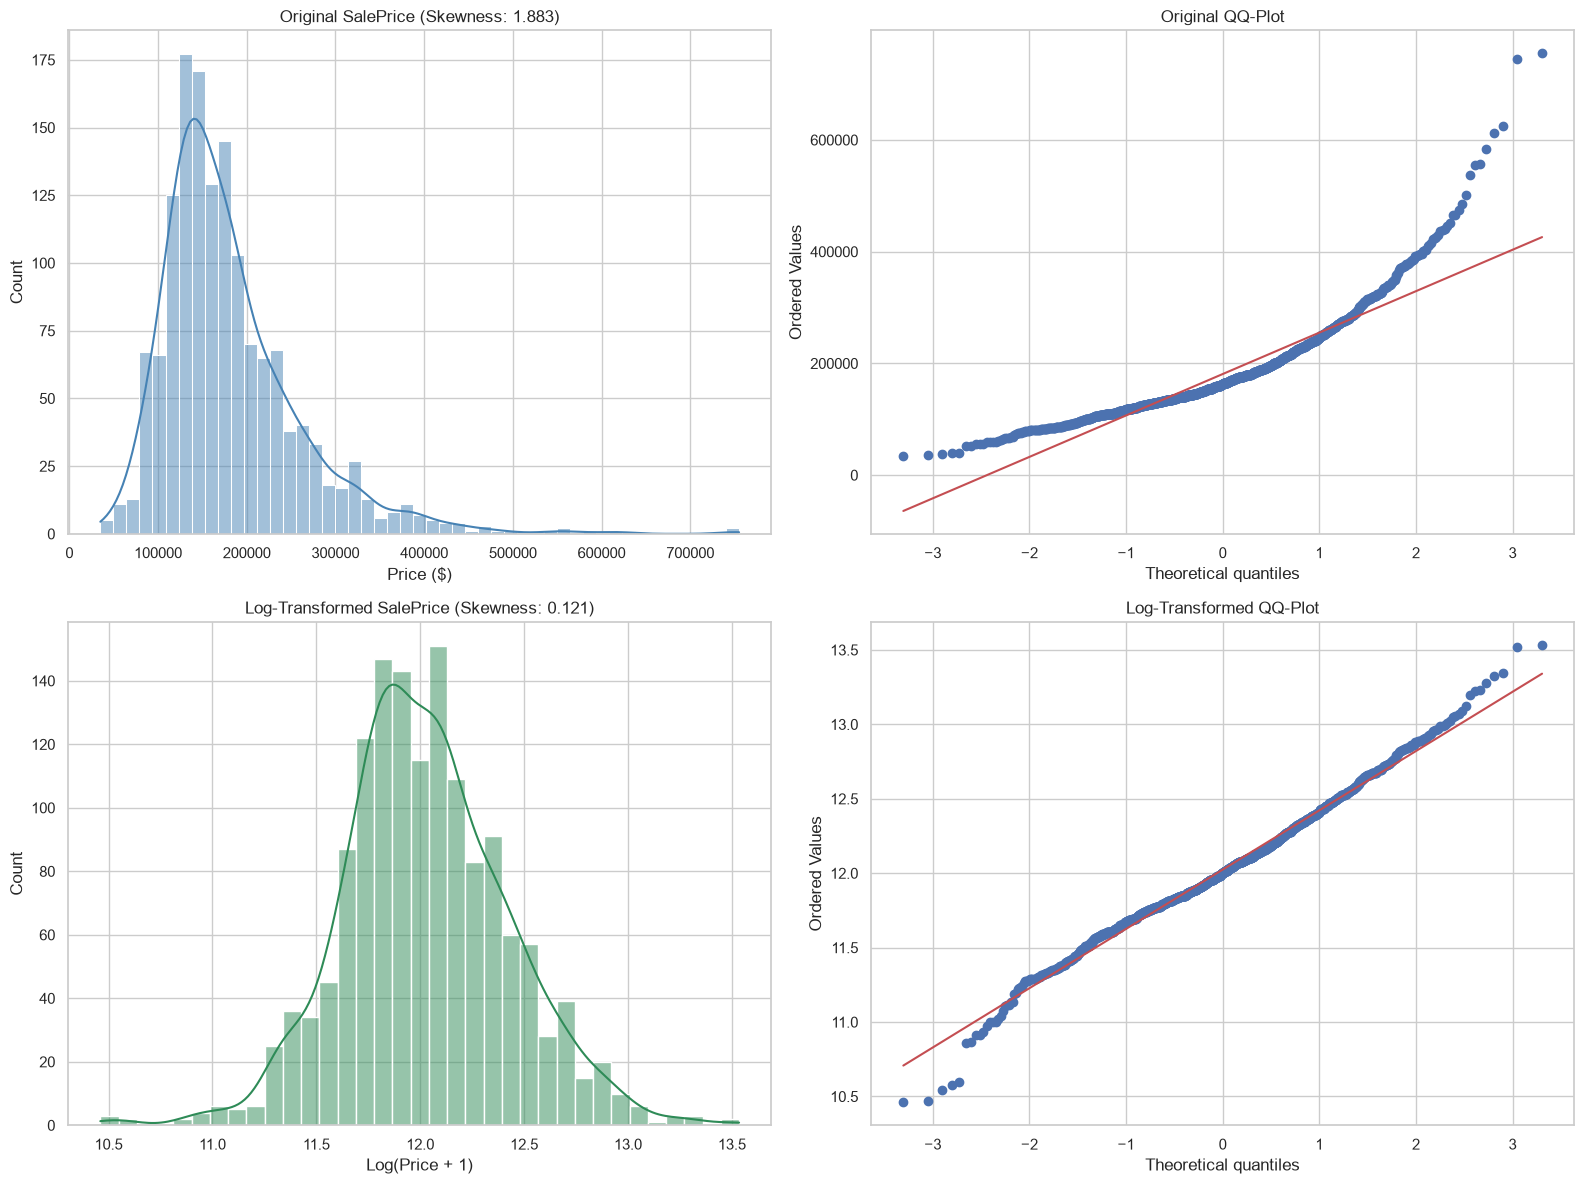

Observation: The log1p transformation successfully reduces skewness, bringing the distribution much closer to a normal distribution as seen in the QQ-Plot. We will integrate this transformation directly into our modeling pipeline.


In [3]:
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Original Distribution
sns.histplot(df['SalePrice'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title(f'Original SalePrice (Skewness: {df["SalePrice"].skew():.3f})')
axes[0, 0].set_xlabel('Price ($)')

# 2. Original QQ-Plot
stats.probplot(df['SalePrice'], plot=axes[0, 1])
axes[0, 1].set_title('Original QQ-Plot')

# 3. Log Transformation (np.log1p)
log_SalePrice = np.log1p(df['SalePrice'])

# 4. Log-Transformed Distribution
sns.histplot(log_SalePrice, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title(f'Log-Transformed SalePrice (Skewness: {log_SalePrice.skew():.3f})')
axes[1, 0].set_xlabel('Log(Price + 1)')

# 5. Log-Transformed QQ-Plot
stats.probplot(log_SalePrice, plot=axes[1, 1])
axes[1, 1].set_title('Log-Transformed QQ-Plot')

plt.tight_layout()
plt.show()

print("Observation: The log1p transformation successfully reduces skewness, bringing the distribution much closer to a normal distribution as seen in the QQ-Plot. We will integrate this transformation directly into our modeling pipeline.")

**Observation:** The skewness drops from **1.883** (raw `SalePrice`) to **0.121** after `np.log1p`, and the log-scale QQ-plot follows the reference line closely, with only small deviations in the tails. The right skew is not caused only by a few extreme sales: prices behave multiplicatively (a better neighborhood or higher quality scales the price rather than adding a fixed amount), so the whole upper tail is stretched.

We will apply the transformation to the target inside the modeling pipeline (`TransformedTargetRegressor`), so the final predictions are still returned in dollars.

## 3. Missing Values Analysis

Identifying which columns contain missing data and their respective missing ratios is essential for selecting the appropriate imputation strategies in our Scikit-Learn Pipeline.

In [21]:
# Calculate missing data percentages
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# Display as a styled DataFrame
missing_df = pd.DataFrame({'Missing Ratio (%)': missing_data})
display(missing_df.head(15).style.background_gradient(cmap='Reds'))

,Missing Ratio (%)
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


**Observation on Missing Values:**
Variables such as `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, and the `Garage*` / `Bsmt*` features have a very high percentage of `NaN`s. However, domain knowledge of the Ames dataset indicates that these are mostly not "missing data" but represent the **absence of the feature** (e.g., `NaN` in `PoolQC` means the house has no pool). `LotFrontage` is one of the few columns where the values are genuinely missing.

* **Categorical features:** filling `NaN` with the constant string `'Missing'` preserves the "feature absent" information as its own category.
* **Numerical features:** for columns such as `GarageYrBlt`, imputing a year for a house without a garage is logically flawed. We therefore use `SimpleImputer(strategy='median', add_indicator=True)`: the median keeps the model input valid, while the indicator column (created only for numeric columns that contain missing values in the training data) tells the model that the original value was absent. In addition, we create explicit `HasGarage` / `HasPool` flags during feature engineering.

## 4. Numerical Features vs. SalePrice (Bivariate Analysis)

First we inspect the pairwise correlations (Pearson for linear, Spearman for monotonic relationships) and check for near-constant categorical columns. Then we use scatter plots to observe the relationship between `SalePrice` and key numerical features. The scatter plots are also crucial for spotting extreme observations that might negatively impact model performance.

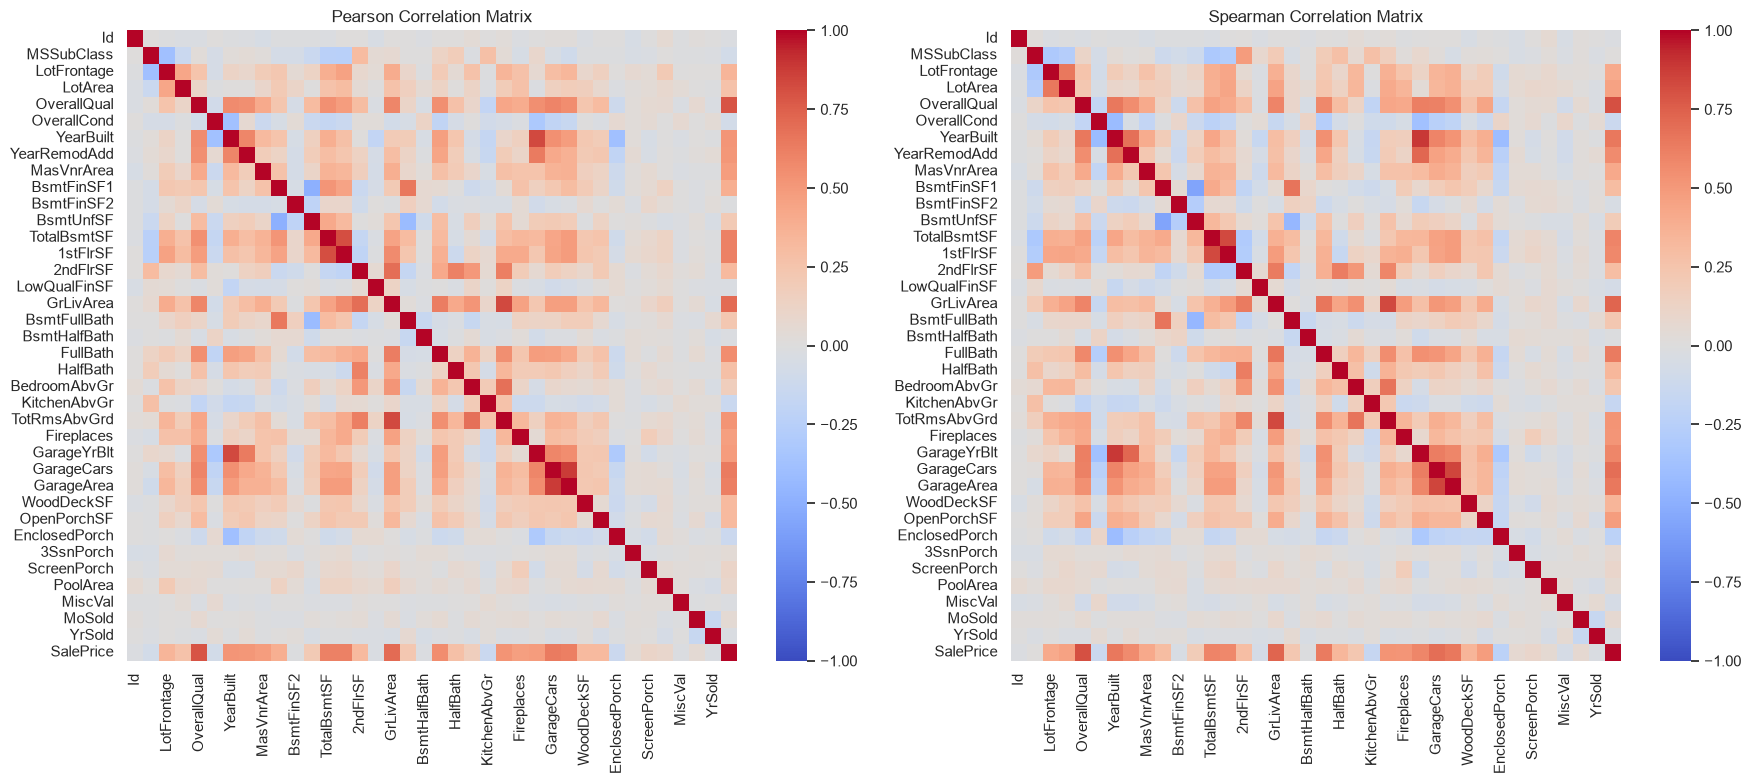

In [4]:
# Select only numeric columns for correlation
num_df = df.select_dtypes(include='number')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pearson Correlation (Linear relationships)
sns.heatmap(num_df.corr(method='pearson').round(2), cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation Matrix')

# Spearman Correlation (Non-linear monotonic relationships)
sns.heatmap(num_df.corr(method='spearman').round(2), cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation Matrix')

plt.tight_layout()
plt.show()

**Observation on Multicollinearity:**
The heatmaps show strongly correlated feature pairs, for example `GarageCars` and `GarageArea`, `TotalBsmtSF` and `1stFlrSF`, and `GrLivArea` and `TotRmsAbvGrd`. This redundancy mainly matters for linear models (unstable coefficients); tree-based models are largely insensitive to it. In the feature engineering step we add aggregated features (`TotalSF`, `TotalBath`), but the original columns are **kept** in the dataset.

In [5]:
# Check for features where one category dominates (>95%)
threshold = 0.95
for col in df.select_dtypes(exclude='number').columns:
    max_freq = df[col].value_counts(normalize=True).max()
    if max_freq > threshold:
        print(f"Feature '{col}': Most frequent category represents {max_freq*100:.1f}% of data.")

Feature 'Street': Most frequent category represents 99.6% of data.
Feature 'Utilities': Most frequent category represents 99.9% of data.
Feature 'Condition2': Most frequent category represents 99.0% of data.
Feature 'RoofMatl': Most frequent category represents 98.2% of data.
Feature 'Heating': Most frequent category represents 97.8% of data.
Feature 'GarageQual': Most frequent category represents 95.1% of data.
Feature 'GarageCond': Most frequent category represents 96.2% of data.


**Observation on Near-Constant Features:**
Seven categorical columns are dominated by a single category (>95%): `Street`, `Utilities`, `Condition2`, `RoofMatl`, `Heating`, `GarageQual` and `GarageCond`. They carry almost no information. In the modeling phase we drop `Street` and `Utilities`; the others are kept for now (see the summary below).

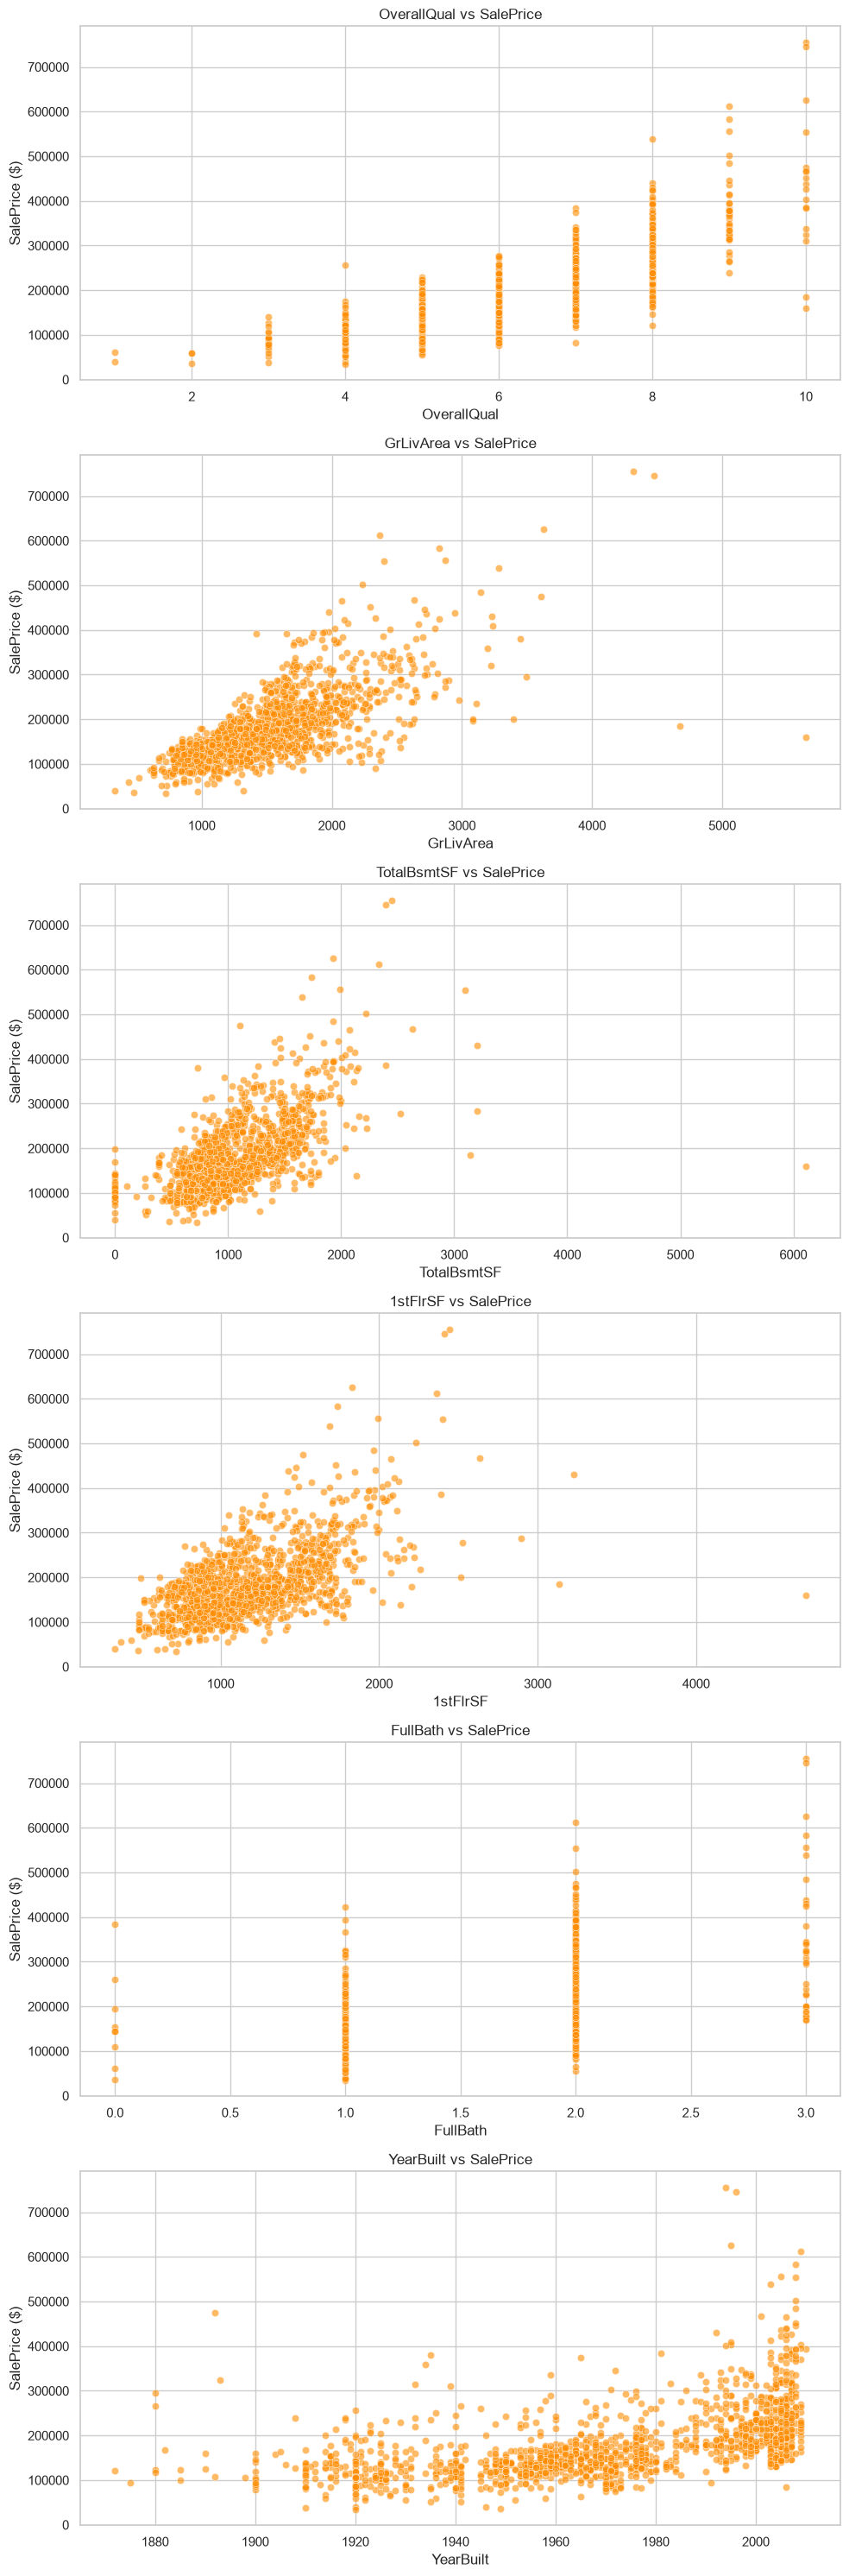

In [ ]:
# Select a few key numerical features to investigate
num_features = ["OverallQual","GrLivArea","TotalBsmtSF","1stFlrSF","FullBath","YearBuilt"]

fig, axes = plt.subplots(len(num_features), 1, figsize=(10, 5 * len(num_features)))

for i, col in enumerate(num_features):
    sns.scatterplot(data=df, x=col, y='SalePrice', ax=axes[i], alpha=0.6, color='darkorange')
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].set_ylabel('SalePrice ($)')
    
plt.tight_layout()
plt.show()

**Observations:**
* All selected variables are positively correlated with `SalePrice`, and the scatter plots are consistent with the correlation results (`OverallQual` and `GrLivArea` show the clearest upward trends).
* Two types of extreme points are visible. The expensive homes at the top of the price range (≈ $600-750k) follow the general trend of size and quality, so they are legitimate luxury sales.
* In contrast, a few houses with a very large area (`GrLivArea` > 4000, `TotalBsmtSF` > 6000, `1stFlrSF` > 4500) have **low prices (≈ $160-185k)** and sit far below the trend. These look like unusual sales (e.g., partial or abnormal sale conditions) rather than market signal, and they can distort models that are sensitive to leverage points (especially linear models).

## 5. Categorical Features vs. SalePrice

We examine location (`Neighborhood`), building characteristics (`BldgType`, `HouseStyle`, `CentralAir`) and a quality indicator (`KitchenQual`) using boxplots. (`OverallQual` is stored as a number and was analyzed in the previous section.) Note that several quality features such as `KitchenQual`, `ExterQual` and `HeatingQC` are ordinal and are encoded accordingly in the modeling phase.

In [ ]:
# List categorical columns
cat_cols = df.select_dtypes(include="object").columns
print(cat_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\489604010.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


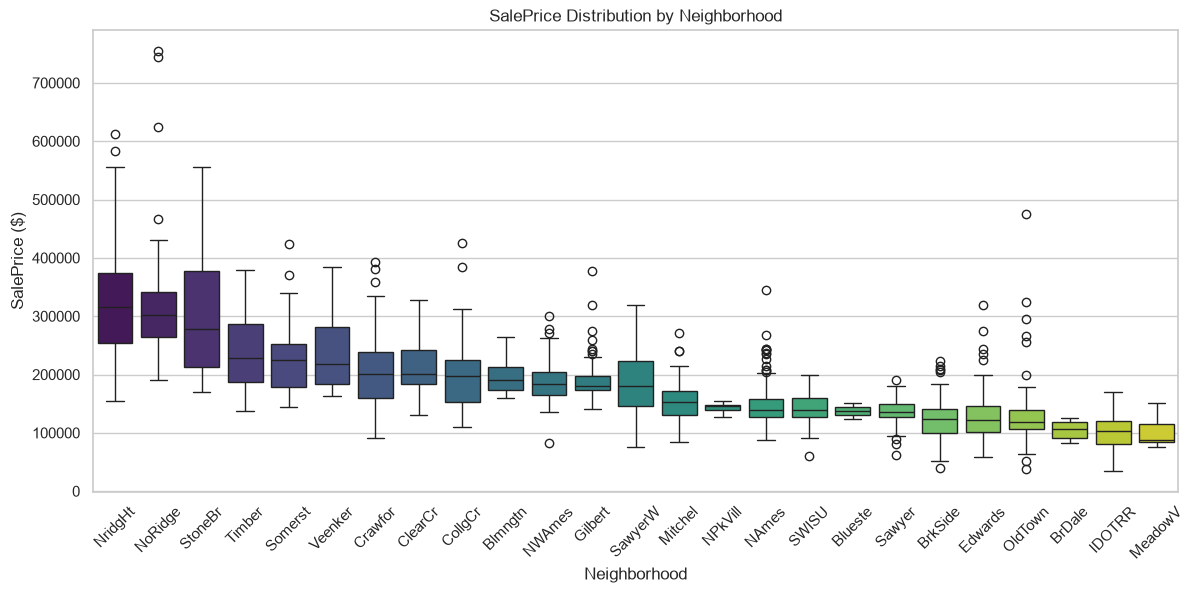

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


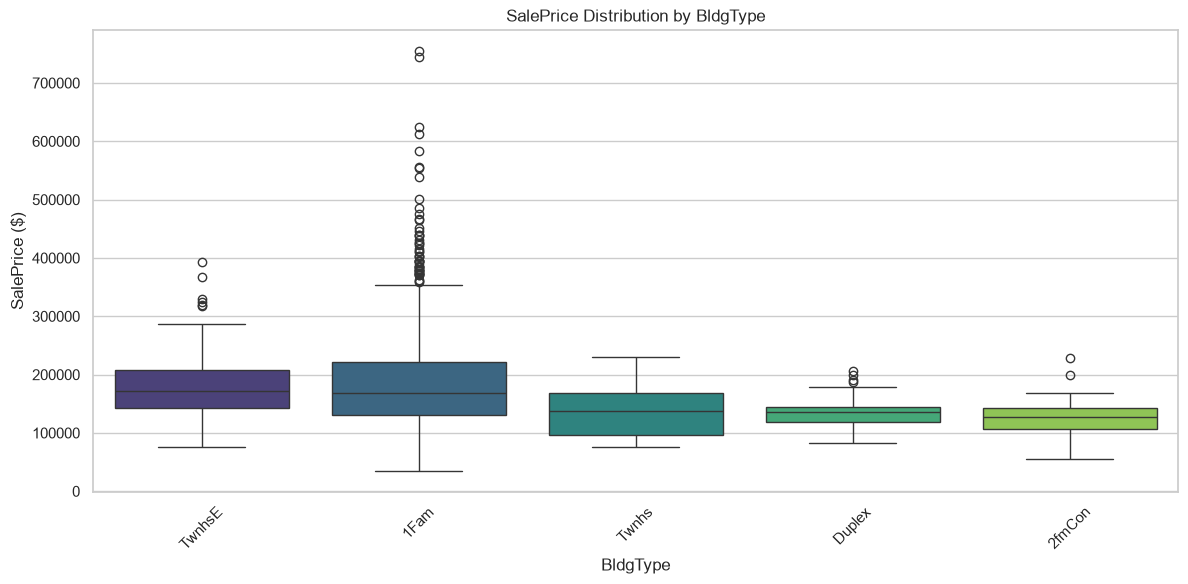

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


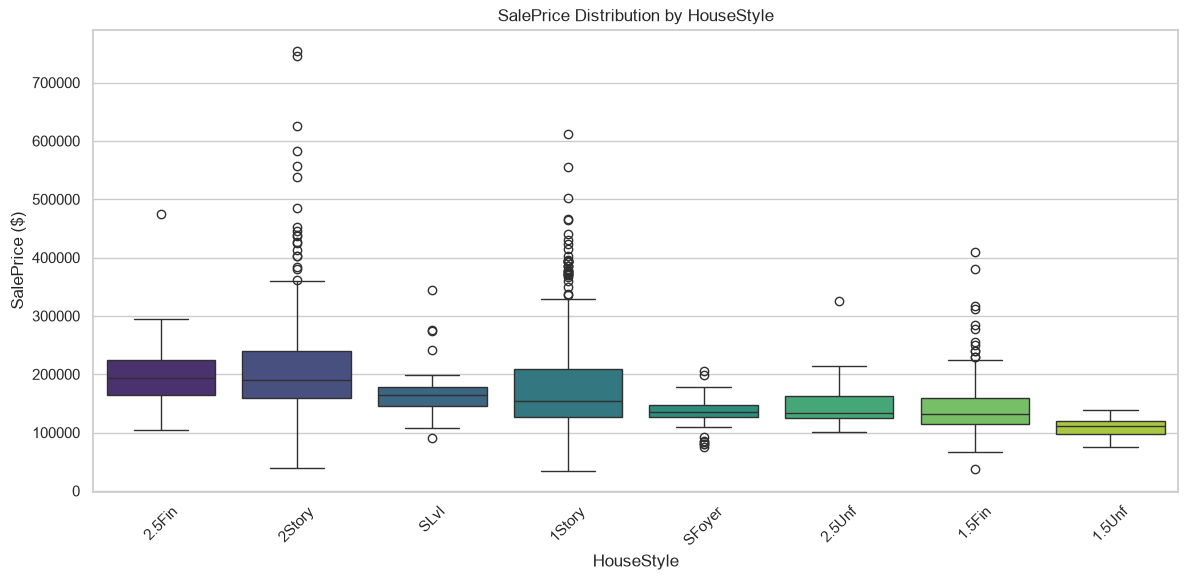

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


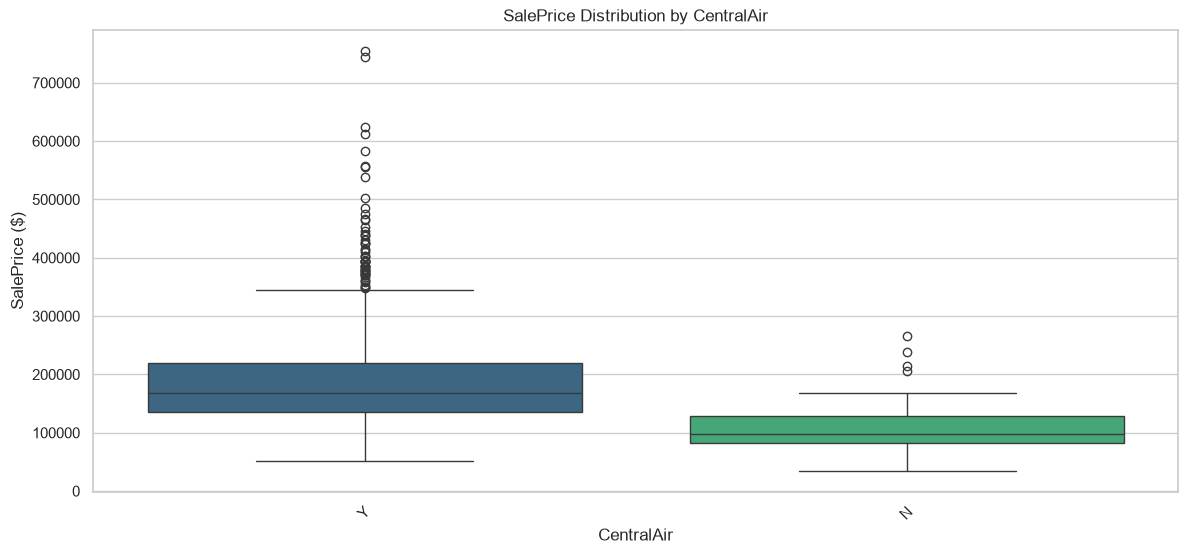

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


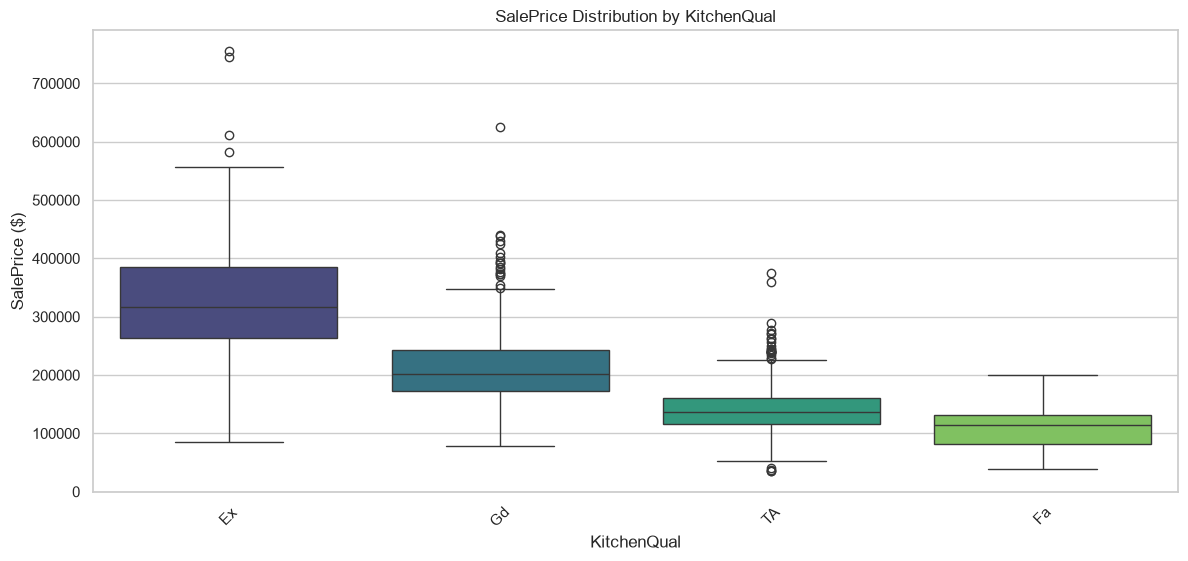

In [ ]:
# Select key categorical or ordinal features to investigate
cat_features = ['Neighborhood', 'BldgType','HouseStyle','CentralAir','KitchenQual']

for col in cat_features:
    plt.figure(figsize=(12, 5))
    sorted_order = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis', hue=col, legend=False)
    plt.title(f'SalePrice Distribution by {col}')
    plt.xticks(rotation=45)
    plt.show()

**Observations:**
* Median `SalePrice` rises with the quality level (e.g., `KitchenQual`), and `Neighborhood` produces a large spread between the cheapest and the most expensive areas.
* In some high-quality categories the price distribution is broader, i.e., home prices vary more within those categories.
* Across almost all categorical features, outliers are concentrated at the **upper** end of the price range. This is typical for real estate: prices have a lower bound set by land and construction costs, but practically no upper limit for luxury materials, large lots or premium locations.

Because tree-based models split on thresholds, such high-price observations do not distort them the way they would distort a linear model, so we keep them. The suspicious low-price / very-large-area houses identified in Section 4 are a separate issue and are **not** removed yet.

## EDA Summary & Pipeline Strategy
Based on the exploratory analysis, the modeling pipeline implements the following strategies:
1. **Target Transformation:** `np.log1p` on `SalePrice` through `TransformedTargetRegressor` (skewness 1.883 → 0.121).
2. **Feature Engineering:** `TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`, `HasGarage`, `HasPool`; `MSSubClass` is converted to a categorical variable; `Id`, `Street` and `Utilities` are dropped. The original component columns and the other near-constant columns (`Condition2`, `RoofMatl`, `Heating`, `GarageQual`, `GarageCond`) are kept.
3. **Imputation:** median imputation with missing-value indicators (`add_indicator=True`) for numerical features; constant `'Missing'` for categorical features.
4. **Encoding:** ordinal encoding (`Po < Fa < TA < Gd < Ex`) for `ExterQual`, `KitchenQual` and `HeatingQC`; one-hot encoding for all remaining categorical variables (including the other quality columns such as `BsmtQual` or `FireplaceQu`).
5. **Scaling:** no scaler is used, since the final candidates are tree-based models.
6. **Outliers:** high-price homes are retained as legitimate observations. The few very large but low-priced houses (Section 4) are an **open decision**: they are currently not removed.